# CineMatch: from movie metadata to recommendations

This notebook develops the same content-based model used by the website. No LLM, user ratings, or remote recommendation service is used. Run cells from top to bottom with the project virtual environment. Dataset provenance and terms live in `backend/data`.

**Series update:** This notebook retains the movie-only baseline. The website now fits `load_catalog()` (movies + TVmaze series), so its IDF weights and scores differ. To explore the joint model, replace `load_movies()` with `load_catalog()` after importing it from `backend.app.data`, and rerun all cells.

## 1. Load the dataset
A dataframe is a table. MovieLens gives us one movie per row, a stable ID, a title and pipe-separated genres. Paths work from the repository root or this notebook folder.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'backend').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from backend.app.data import load_movies, content_features
from backend.app.recommender import Recommender
raw = pd.read_csv(ROOT / 'backend/data/movies.csv')
raw.head()

Matplotlib is building the font cache; this may take a moment.


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Inspect the data
Check shape, missing values, duplicate IDs, and examples before modeling. Never assume clean inputs.

In [2]:
print('Rows, columns:', raw.shape)
print('Duplicate IDs:', raw.movieId.duplicated().sum())
raw.isna().sum()

Rows, columns: (9742, 3)
Duplicate IDs: 0


movieId    0
title      0
genres     0
dtype: int64

## 3. Handle missing values and normalize
The shared loader fills missing titles, drops duplicate IDs, extracts years, splits genres, and removes the missing-genre marker. It also removes IMAX: a display format can look statistically distinctive while saying little about story content. Missing TMDB IDs stay optional.

In [3]:
movies = load_movies()
movies[['movieId', 'title', 'year', 'genres']].head()

,movieId,title,year,genres
0,1,Toy Story,1995.0,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji,1995.0,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men,1995.0,"[Comedy, Romance]"
3,4,Waiting to Exhale,1995.0,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II,1995.0,[Comedy]


## 4. Explore genres
Explode turns each genre in a list into a separate row. A movie can count in more than one genre, so counts exceed the catalog size.

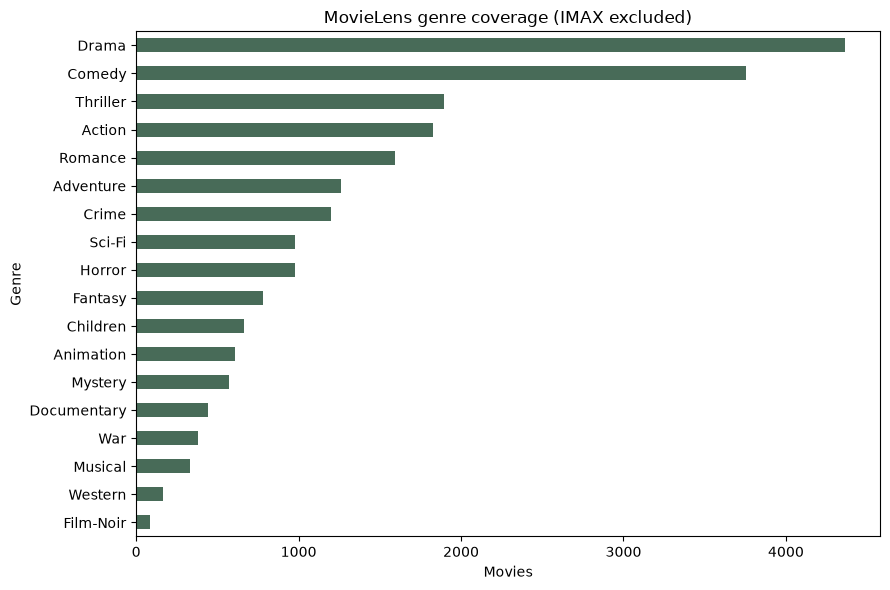

In [4]:
genre_counts = movies.genres.explode().dropna().value_counts()
ax = genre_counts.sort_values().plot.barh(figsize=(9, 6), color='#486b58')
ax.set(title='MovieLens genre coverage (IMAX excluded)', xlabel='Movies', ylabel='Genre')
plt.tight_layout()
plt.show()

## 5. Build combined text features
Each genre is repeated three times to emphasize genre similarity over incidental title words. Sci-Fi is normalized to scifi, a single token. This weight is a simple, explicit hyperparameter; it has not been tuned against user judgments.

In [5]:
favorites = movies[movies.title.isin(['Interstellar', 'Inception'])]
favorites[['movieId', 'title', 'features']]

,movieId,title,features
7372,79132,Inception,action crime drama mystery scifi thriller acti...
8376,109487,Interstellar,scifi scifi scifi interstellar


## 6. TF-IDF vectorization
Term frequency counts a term within a movie. Inverse document frequency downweights terms seen across many movies. With scikit-learn’s smoothing: idf = log((1 + N)/(1 + df)) + 1. Multiply counts by IDF, then normalize each row to unit length. English stop words are removed. This is a bag of words: word order and meaning are not understood.

In [6]:
vectorizer = TfidfVectorizer(stop_words='english', strip_accents='unicode', dtype=np.float64)
X = vectorizer.fit_transform(movies.features)
terms = vectorizer.get_feature_names_out()
print('TF-IDF matrix shape:', X.shape)

TF-IDF matrix shape: (9742, 8914)


## 7. What do the dimensions mean?
Rows are movies and columns are vocabulary terms. Most entries are zero, so we keep a sparse matrix. Only a small selected row is converted to a dense array for inspection.

In [7]:
print('Nonzero entries:', X.nnz)
print('Density:', X.nnz / (X.shape[0] * X.shape[1]))
i = movies.index[movies.title == 'Interstellar'][0]
row = X[i].toarray().ravel()
pd.DataFrame({'term': terms[row > 0], 'weight': row[row > 0]}).sort_values('weight', ascending=False)

Nonzero entries: 43761
Density: 0.0005039256709117212


,term,weight
1,scifi,0.721407
0,interstellar,0.692511


## 8. Cosine similarity
Cosine = dot(a, b) / (length(a) × length(b)). Shared nonzero columns contribute to the dot product. TF-IDF values are nonnegative, giving a 0–1 score here. We compare one profile to the catalog, avoiding an expensive all-movie-pairs matrix.

In [8]:
scores = cosine_similarity(X[i], X).ravel()
print('Self-similarity:', scores[i])
assert np.isclose(scores[i], 1)

Self-similarity: 1.0


## 9. Recommend from one favorite
Sort descending, remove the favorite, and take ten positive matches. The production module adds deterministic explanations and stable tie-breaking.

In [9]:
ranking = np.argsort(-scores, kind='stable')
top = [j for j in ranking if j != i and scores[j] > 0][:10]
single = movies.iloc[top][['movieId','title','genres']].copy()
single['cosine'] = scores[top]
single

,movieId,title,genres,cosine
4630,6899,Alien from L.A.,[Sci-Fi],0.569183
2267,3008,Last Night,"[Drama, Sci-Fi]",0.564372
6059,40697,Babylon 5,[Sci-Fi],0.564104
5511,26467,"Day After, The","[Drama, Sci-Fi]",0.558107
8211,103596,Sharknado,[Sci-Fi],0.538932
2492,3326,What Planet Are You From?,"[Comedy, Sci-Fi]",0.533789
1902,2526,Meteor,[Sci-Fi],0.531188
4122,5919,Android,[Sci-Fi],0.531188
7328,77795,Cargo,[Sci-Fi],0.531188
9392,164179,Arrival,[Sci-Fi],0.531188


## 10. Average multiple favorites
Average normalized movie rows to give every favorite an equal vote. The average itself need not have unit length: cosine_similarity normalizes it during comparison. Duplicate favorites are removed in the app.

In [10]:
indices = movies.index[movies.title.isin(['Interstellar', 'Inception'])].tolist()
taste = np.asarray(X[indices].mean(axis=0))
multi_scores = cosine_similarity(taste, X).ravel()
model = Recommender(movies)
ids = movies.iloc[indices].movieId.astype(int).tolist()
recommendations = model.recommend(ids)
pd.DataFrame([{'title': r['title'], 'cosine': r['score'], 'shared_genres': r['shared_genres']} for r in recommendations])

,title,cosine,shared_genres
0,Strange Days,0.698319,"[Sci-Fi, Action, Crime, Drama, Mystery, Thriller]"
1,"One, The",0.687250,"[Sci-Fi, Action, Thriller]"
2,Next,0.687250,"[Sci-Fi, Action, Thriller]"
3,Watchmen,0.670485,"[Sci-Fi, Action, Drama, Mystery, Thriller]"
4,Knowing,0.665149,"[Sci-Fi, Action, Drama, Mystery, Thriller]"
5,Moon,0.664117,"[Sci-Fi, Drama, Mystery, Thriller]"
6,Cloverfield,0.659804,"[Sci-Fi, Action, Mystery, Thriller]"
7,Self/less,0.659804,"[Sci-Fi, Action, Mystery, Thriller]"
8,RoboCop 3,0.654899,"[Sci-Fi, Action, Crime, Drama, Thriller]"
9,RoboCop,0.654899,"[Sci-Fi, Action, Crime, Drama, Thriller]"


## 11. Explain one real score
Normalize the taste vector and multiply its weights with a recommended movie’s weights. Summing all per-term contributions reconstructs cosine similarity. The API shows the strongest six terms; sometimes more terms contribute.

In [11]:
best = recommendations[0]
j = model.id_to_index[best['id']]
taste_unit = taste.ravel() / np.linalg.norm(taste)
contributions = X[j].multiply(taste_unit).tocsr()
print(best['title'], best['score'])
print('Sum of ALL term contributions:', contributions.sum())
assert np.isclose(contributions.sum(), best['score'])
pd.DataFrame(best['shared_features'])

Strange Days 0.6983194960848875
Sum of ALL term contributions: 0.6983194960848874


,term,contribution
0,scifi,0.291049
1,mystery,0.143157
2,crime,0.093781
3,action,0.070105
4,thriller,0.068286
5,drama,0.031942


## 12. Evaluation and score distribution
Genre overlap is a sanity check, not accuracy: our model already uses genres. Inspect the full candidate score distribution rather than just winners. We have no held-out relevance labels and make no precision/recall claim.

Mean genre Jaccard@10: 0.7333333333333332
count    9740.000000
mean        0.116122
std         0.142074
min         0.000000
25%         0.000000
50%         0.057065
75%         0.175846
max         0.698319
dtype: float64


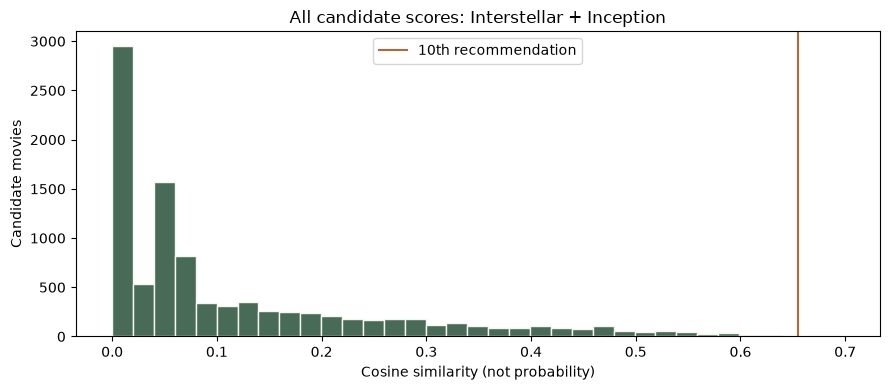

In [12]:
favorite_genres = set(g for index in indices for g in movies.iloc[index].genres)
overlap = [len(favorite_genres & set(r['genres'])) / len(favorite_genres | set(r['genres'])) for r in recommendations]
print('Mean genre Jaccard@10:', np.mean(overlap))
candidate_scores = np.delete(multi_scores, indices)
print(pd.Series(candidate_scores).describe())
plt.figure(figsize=(9, 4))
plt.hist(candidate_scores, bins=35, color='#486b58', edgecolor='#f6f5ef')
plt.axvline(recommendations[-1]['score'], color='#b0683c', label='10th recommendation')
plt.xlabel('Cosine similarity (not probability)')
plt.ylabel('Candidate movies')
plt.title('All candidate scores: Interstellar + Inception')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Compare several tastes
Try animation and crime profiles too. A system that produces plausible sci-fi recommendations can still behave poorly elsewhere.

In [13]:
for titles in [['Toy Story', 'Finding Nemo'], ['Godfather, The', 'Goodfellas']]:
    selected = [model.search(title)[0]['id'] for title in titles]
    print('Favorites:', titles)
    for recommendation in model.recommend(selected, 3):
        print(' ', recommendation['title'], round(recommendation['score'], 3))

Favorites: ['Toy Story', 'Finding Nemo']
  Toy Story 2 0.912
  Toy Story 3 0.912
  Wild, The 0.859
Favorites: ['Godfather, The', 'Goodfellas']
  Godfather: Part II, The 0.825
  We Own the Night 0.759
  Boy A 0.734


## 14. Limits and your next experiment

- Similarity bubbles: the model repeats familiar content.
- New movies need useful metadata; this catalog is a 2018 snapshot.
- Titles and genres cannot capture mood, acting, director, or plot.
- No cross-user learning or rating-based quality judgment.
- Title terms can favor sequels, and stop-word removal can make distinct titles have identical vectors.
- More similar is not necessarily more enjoyable.

**Your experiment:** change the genre repetition from 3 to 1 in a separate notebook feature column. Refit and compare top ten recommendations for five fixed profiles. Record which version you prefer before looking at scores. Do not silently modify the production model. Next learn held-out ranking evaluation, collaborative filtering, and hybrid systems.